In [1]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import ast
from pprint import pprint
import matplotlib.pyplot as plt
import pyproj
from shapely.geometry import LineString
from collections import defaultdict
import math
from haversine import haversine, Unit, inverse_haversine
from matplotlib.colors import to_rgb, to_hex
import csv


# mappymatch imports
from mappymatch.constructs.trace import Trace
from mappymatch.maps.nx.nx_map import NxMap
from mappymatch.matchers.lcss.lcss import LCSSMatcher
pd.set_option('future.no_silent_downcasting', True)

In [ ]:
# Define bbox manually
north = 41.35771290159195
south = 40.9990363866696
west  = -8.739966476287791
east  = -8.459738123284369


bbox = (west, south, east, north)
# Fetch network from the bounding box
G_bbox = ox.graph_from_bbox(
    bbox=bbox,
    network_type="drive",   # can be 'drive', 'walk', etc.
    simplify=True,
)

# Project to local CRS (UTM Zone 29N, or Mercator 3857)
porto_crs = 3857
G = ox.project_graph(G_bbox, to_crs=porto_crs)

# Add geometry to edges that don't have it
for u, v, k, data in G.edges(keys=True, data=True):
    if 'geometry' not in data:
        point_u = (G.nodes[u]['x'], G.nodes[u]['y']) # x is long, y is lat
        point_v = (G.nodes[v]['x'], G.nodes[v]['y'])
        data['geometry'] = LineString([point_u, point_v])
        

### Plotting top 10 most used links

In [ ]:
""" Loading all mapped routes """
file_name = "part_3_routes_path.csv" 

routes = []

with open(file_name, newline="") as f:
    reader = csv.reader(f)
    next(reader)  # skip header if it exists

    count = 0
    for row in reader:
        # Convert each string tuple to actual tuple using ast.literal_eval
        route_tuples = [ast.literal_eval(tup_str) for tup_str in row]
        routes.append(route_tuples)
        count += 1

print(f"Loaded {len(routes)} routes")


# Quick reference dict: (u,v,key) -> data
edge_data_dict = {
    (u, v, k): data
    for u, v, k, data in G.edges(keys=True, data=True)
}



Loaded 1500 routes



### Top 10 link counts

To count top 10 links, for each link in a route, its canonical nodes are stored , u = smaller, v = larger. This breaks some ties, but a lot more remain, thus to further resolve ties, longer links are prioritized.

Top 10 edges and counts (tie-broken by length):
1. Edge (90376961->279915425), Count: 154, Length: 755.09, Geometry start/end: (-964919.0939121008, 5046315.123274487) -> (-964895.3383327654, 5047269.363904782)
2. Edge (279907160->279915425), Count: 148, Length: 370.15, Geometry start/end: (-964695.842673315, 5045908.972301357) -> (-964919.0939121008, 5046315.123274487)
3. Edge (90376961->1235787118), Count: 143, Length: 1197.33, Geometry start/end: (-964895.3383327654, 5047269.363904782) -> (-965084.6371268594, 5047472.228955542)
4. Edge (279907004->280240272), Count: 138, Length: 558.76, Geometry start/end: (-963074.2516509292, 5042601.962914875) -> (-963114.0817647352, 5043338.494110388)
5. Edge (279907037->279916540), Count: 138, Length: 302.62, Geometry start/end: (-964345.3643885013, 5045434.5195582155) -> (-964579.9368195009, 5045761.968796132)
6. Edge (25620737->25620743), Count: 138, Length: 73.49, Geometry start/end: (-958603.9280674492, 5034179.6429410195) -> (-958701.1767746

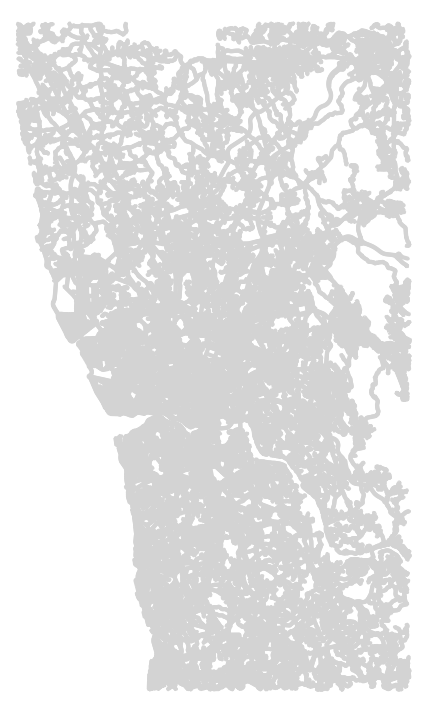

In [ ]:
# Count how many times each (u,v) edge appears
link_counts = defaultdict(int)
link_lengths = {}  # store length for tie-breaking
link_geoms = {}    # store geometry for plotting

for route in routes:  # each route is a list of Route objects
    if len(route) == 0: continue
    for start, end, key in route:
        u, v = sorted([start, end])  # canonical ordering
        link_counts[(u, v)] += 1

        # Store geometry if not already stored
        if (u, v) not in link_geoms:
            data_key = (u,v,key) if (u,v,key) in edge_data_dict else (v,u,key)
            link_geoms[(u, v)] = edge_data_dict[data_key]['geometry']
            link_lengths[(u, v)] = edge_data_dict[data_key]['length'] # store length for tie-break

# Get top N edges with tie-breaking by length
N = 10
top_links = sorted(
    link_counts.items(),
    key=lambda x: (x[1], link_lengths[x[0]]),  # sort by count, then length
    reverse=True
)[:N]

print(f"Top {N} edges and counts (tie-broken by length):")
for i, ((u, v), count) in enumerate(top_links, 1):
    geom = link_geoms[(u, v)]
    length = link_lengths[(u, v)]
    print(f"{i}. Edge ({u}->{v}), Count: {count}, Length: {length:.2f}, "
          f"Geometry start/end: {geom.coords[0]} -> {geom.coords[-1]}")


# --- Plot base OSM graph (limited to bbox) ---
fig, ax = ox.plot_graph(
        G,
        figsize=(15,9),
        bgcolor="white",
        node_size=6,
        node_color="lightgray",
        node_zorder=1,
        edge_color="lightgray",
        edge_linewidth=3,
        show=False,
        close=False,
    )


# --- Compute bounding box from top link coordinates ---
all_x, all_y = [], []
for link, _ in top_links:
    geom = link_geoms[link]
    x, y = geom.xy
    all_x.extend(x)
    all_y.extend(y)

# Add 5% padding
pad_x = (max(all_x) - min(all_x)) * 0.05
pad_y = (max(all_y) - min(all_y)) * 0.05
x_min, x_max = min(all_x) - pad_x, max(all_x) + pad_x
y_min, y_max = min(all_y) - pad_y, max(all_y) + pad_y

# --- Plot base OSM graph ---
fig, ax = ox.plot_graph(
    G,
    figsize=(15, 9),
    bgcolor="white",
    node_size=6,
    node_color="lightgray",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=3,
    show=False,
    close=False,
)

# Limit view to bounding box
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# --- Plot top links ---
for i, (link, link_count) in enumerate(top_links):
    geom = link_geoms[link]
    x, y = geom.xy
    ax.plot(x, y, linewidth=3, alpha=0.8, zorder=4, label=f"Top Link {i+1}")

# --- Styling ---
ax.set_title("Top 15 Most Traversed Links on Road Network", fontsize=8, y=0.95)
ax.legend(loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="black")

fig.savefig("LCSS_Images/top_links_on_network_part_5_1.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.close(fig)


### Plotting Most slowest links

In [ ]:
""" Loading all roads links that matched to gps points """
file_name = "part_3_matches.csv" 

matches = []

with open(file_name, newline="") as f:
    reader = csv.reader(f)
    next(reader)  # skip header if it exists

    count = 0
    for row in reader:
        # Convert each string tuple to actual tuple using ast.literal_eval
        route_tuples = [ast.literal_eval(tup_str) for tup_str in row]
        matches.append(route_tuples)
        count += 1

print(f"Loaded {len(matches)} matches")


Loaded 1500 matches


In [ ]:
matches[0]

[(286969943, 1788784885, 0),
 (286969943, 1788784885, 0),
 (1788784885, 122549700, 0),
 (1788784885, 122549700, 0),
 (122549700, 111467467, 0),
 (122549700, 111467467, 0),
 (111467467, 478821940, 0),
 (111467467, 478821940, 0),
 (478821668, 111467271, 0),
 (478632189, 1143316313, 0),
 (1143316313, 297880608, 0),
 (297880608, 427067714, 0),
 (297880608, 427067714, 0),
 (285945659, 128673222, 0),
 (285945659, 128673222, 0),
 (128673222, 128673223, 0),
 (128673223, 1788786316, 0),
 (1418798472, 3092543648, 0),
 (2244990442, 129800102, 0),
 (129800102, 129800097, 0),
 (129800102, 129800097, 0),
 (129800102, 129800097, 0),
 (129800102, 129800097, 0)]

In [ ]:

# Container: canonical_road -> [total_points, total_routes]
link_stats = defaultdict(lambda: [0, 0])
link_geoms = {}  # canonical_road -> LineString
N = 10

for match_list in matches:
    # Count GPS points per road (canonical ordering)
    if len(match_list) == 0: continue
    road_counts = defaultdict(float)
    
    for start, end, key  in match_list:
        u, v = sorted([start, end])
        road = (u, v)
        
        # Store geometry if not already stored
        if road not in link_geoms:
            data_key = (start, end, key)
            geom = edge_data_dict[data_key]['geometry']
            if not isinstance(geom, LineString):
                continue  # skip if not a LineString
            link_geoms[road] = geom
        
        # Increment counter for this GPS point
        road_counts[road] += 1.0

    # Subtract 0.5 from first and last road
    first_road = tuple(sorted([match_list[0][0],match_list[0][1] ]))
    last_road = tuple(sorted([match_list[-1][0],match_list[-1][1]] ))
    road_counts[first_road] -= 0.5
    road_counts[last_road] -= 0.5

    # Accumulate total points and route count
    for road, count in road_counts.items():
        link_stats[road][0] += count        # total GPS points
        link_stats[road][1] += 1            # number of routes

# Compute average GPS points per route for each road
avg_points_per_route = {
    road: total_points / total_routes
    for road, (total_points, total_routes) in link_stats.items()
}

# Get top N slowest roads (largest average points per route), tiebreak by road length
top_slowest = sorted(
    avg_points_per_route.items(),
    key=lambda x: (x[1], link_geoms[x[0]].length),  # sort by avg_points, then by length
    reverse=True
)[:N]

# Display results with geometry and length
for rank, (road, avg_points) in enumerate(top_slowest, 1):
    geom = link_geoms[road]
    length = geom.length  # length of the LineString
    print(f"{rank:2d}. Road {road}, avg GPS points per trajectory: {avg_points:.2f}, "
          f"Geometry start/end: {geom.coords[0]} -> {geom.coords[-1]}, Length: {length:.2f}")


#Plotting
fig, ax = ox.plot_graph(
    G,
    figsize=(15, 9),
    bgcolor="white",
    node_size=6,
    node_color="lightgray",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=3,
    show=False,
    close=False,
)

# --- Plot top slowest links ---
# all_x, all_y = [], []  # collect coordinates for bounding box

for i, (link_id, avg_points) in enumerate(top_slowest):
    geom = link_geoms[link_id]  # LineString
    x, y = geom.xy
    ax.plot(x, y, linewidth=3, alpha=0.8, zorder=4, label=f"Slow Link {i+1}")
    all_x.extend(x)
    all_y.extend(y)

# # --- Set bounding box around plotted links with 5% padding ---
# pad_x = (max(all_x) - min(all_x)) * 0.05
# pad_y = (max(all_y) - min(all_y)) * 0.05
# ax.set_xlim(min(all_x) - pad_x, max(all_x) + pad_x)
# ax.set_ylim(min(all_y) - pad_y, max(all_y) + pad_y)

# --- Styling ---
ax.set_title("Top 10 Slowest Links on Road Network (avg GPS points per route)", fontsize=6, y=0.95)
ax.legend(loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="black")

fig.savefig("LCSS_Images/top_slowest_links_part_5_2.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.close(fig)



 1. Road (2076734382, 11005833093), avg GPS points per trajectory: 24.00, Geometry start/end: (-958393.4451742575, 5033631.52709336) -> (-958563.1851338191, 5033791.547463327), Length: 278.10
 2. Road (479184136, 4554424124), avg GPS points per trajectory: 21.25, Geometry start/end: (-961562.6776812945, 5034561.101255621) -> (-961692.4873395087, 5034561.071688064), Length: 133.47
 3. Road (497871638, 6381957361), avg GPS points per trajectory: 20.50, Geometry start/end: (-962972.1716778717, 5037288.72248418) -> (-962998.2427026156, 5037295.1108761765), Length: 26.84
 4. Road (1142603879, 1142605117), avg GPS points per trajectory: 15.58, Geometry start/end: (-956951.2900390815, 5032631.980645719) -> (-957118.0466362897, 5032547.833710641), Length: 379.21
 5. Road (297880483, 297880486), avg GPS points per trajectory: 14.58, Geometry start/end: (-962769.8373714059, 5034880.805725032) -> (-962618.9660655338, 5034844.0816790145), Length: 155.28
 6. Road (479183608, 4554424124), avg GPS po